# Postprocessing of statistics


### First we read the statistics fields
The idea here is that we have already accumulated certain statistics using the statistics toolbox in `neko`.

We only really care about mean fields right now, but for the full documentation of the statistics output file see:

https://neko.cfd/docs/develop/df/d8f/statistics-guide.html

If everything goes well with Tim's script we should have a `fluid_stats0/` folder floating around somewhere.


### PyNekTools

All information about PyNekTools can be found:

https://github.com/ExtremeFLOW/pyNekTools

If you don't have access you can contact Bertie, but if you have access to `neko` you should have access to this.

In [1]:
def load_stats_file(file_name, fld_number):
    # Import required modules
    from mpi4py import MPI #equivalent to the use of MPI_init() in C
    
    # Get mpi info
    comm = MPI.COMM_WORLD
    
    # Hide the log for the notebook. Not recommended when running in clusters as it is better you see what happens
    #import os
    #os.environ["PYNEKTOOLS_HIDE_LOG"] = 'true'
    
    from pynektools.io.ppymech.neksuite import pynekread
    from pynektools.datatypes.msh import Mesh
    

    # set mesh and fld
    
    msh = Mesh(comm, create_connectivity=True)
    fld = FieldRegistry(comm)
    
    # remember the mesh is only stored in the first one!
    # here we're just getting the mesh
    pynekread(file_name+'.f00000', comm, data_dtype=np.double, msh=msh)
    
    # TODO
    # Right now I'm just playing around with one, but ultimately we will take an "average of the averages"
    pynekread(file_name + '.f' + "{:05d}".format(fld_number), comm, data_dtype=np.double, fld=fld)

    return msh, fld

### Plot the 2D velocity field
This isn't necessary, I was just checking that it works. These tools are so nice!!

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from pynektools.datatypes.field import FieldRegistry
import os
os.environ["PYNEKTOOLS_HIDE_LOG"] = 'true'

# path locations
results_path = "../../../results/brinkman_parameters/dt_check/"
brinkman_path = "brinkman/"
meshed_path = "meshed/"
# stats_file = "stats0"
stats_file = "field0"

# IBM
file_name = results_path + brinkman_path + stats_file + '/' + stats_file
brinkman_msh, brinkman_fld = load_stats_file(file_name, 1)

# Meshed
file_name = results_path + meshed_path + stats_file + '/' + stats_file
meshed_msh, meshed_fld = load_stats_file(file_name, 1)

2024-11-10 16:04:06,751 - Mesh - INFO - Initializing empty Mesh object.
2024-11-10 16:04:06,752 - Field - INFO - Initializing empty Field object
2024-11-10 16:04:06,753 - pynekread - INFO - Reading file: ../../../results/brinkman_parameters/dt_check/brinkman/field0/field0.f00000
2024-11-10 16:04:06,776 - Mesh - INFO - Initializing Mesh object from x,y,z ndarrays.
2024-11-10 16:04:06,778 - Mesh - INFO - Initializing common attributes.
2024-11-10 16:04:06,779 - Mesh - INFO - Getting vertices
2024-11-10 16:04:06,781 - Mesh - INFO - Getting edge centers
2024-11-10 16:04:06,819 - Mesh - INFO - Getting facet centers
2024-11-10 16:04:06,869 - Mesh - INFO - Creating connectivity
2024-11-10 16:04:08,517 - Mesh - INFO - Mesh object initialized.
2024-11-10 16:04:08,518 - Mesh - INFO - Mesh data is of type: float64
2024-11-10 16:04:08,519 - Mesh - INFO - Elapsed time: 1.742428787s
2024-11-10 16:04:08,519 - pynekread - INFO - File read
2024-11-10 16:04:08,520 - pynekread - INFO - Elapsed time: 1.76

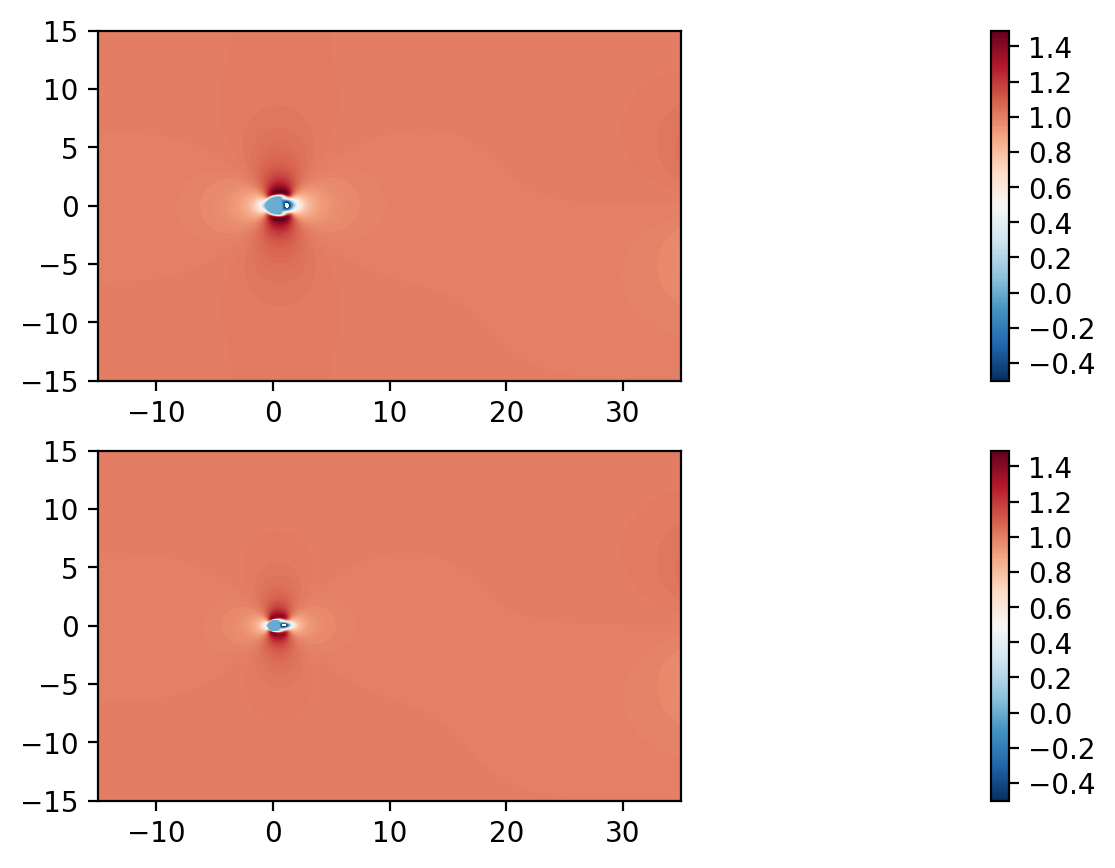

In [3]:
fig, ax = plt.subplots(2,1, figsize=(40, 5), dpi = 200)
c = ax[0].tricontourf(brinkman_msh.x.flatten(), brinkman_msh.y.flatten() ,brinkman_fld.registry["u"].flatten(), levels=np.arange(start=-0.5, stop=1.5, step=0.01), cmap="RdBu_r")
fig.colorbar(c)
ax[0].set_aspect('equal')
c = ax[1].tricontourf(meshed_msh.x.flatten(), meshed_msh.y.flatten() ,meshed_fld.registry["u"].flatten(), levels=np.arange(start=-0.5, stop=1.5, step=0.01), cmap="RdBu_r")
fig.colorbar(c)
ax[1].set_aspect('equal')
plt.show()

## Wake Deficit

We should inspect the wake (of the averaged fields) and some downstream locations.
Right now I'm just plotting them all on the same plot. But I guess what would be more useful is to plot different cases

In [4]:
def generate_wake_lines(msh, fld, wake_positions, y_lims, n_pts):
    # Import required modules
    from mpi4py import MPI #equivalent to the use of MPI_init() in C
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Get mpi info
    comm = MPI.COMM_WORLD
    
    # Hide the log for the notebook. Not recommended when running in clusters as it is better you see what happens
    import os
    os.environ["PYNEKTOOLS_HIDE_LOG"] = 'true'
    
    from pynektools.io.ppymech.neksuite import pynekread
    from pynektools.datatypes.msh import Mesh
    from pynektools.datatypes.coef import Coef
    from pynektools.datatypes.field import FieldRegistry
    from pynektools.postprocessing.file_indexing import index_files_from_folder

    from pynektools.interpolation.probes import Probes
    import pynektools.interpolation.utils as interp_utils
    import pynektools.interpolation.pointclouds as pcs

    # set up the probe locations
    if comm.Get_rank() == 0 :
        # Wake line
        y_1d = pcs.generate_1d_arrays(y_lims, n_pts, mode="equal")
        x_1d = wake_positions
        z_1d = [0.5]
        x, y, z = np.meshgrid(x_1d, y_1d, z_1d, indexing='ij')
        # Write the points for future use
        xyz = interp_utils.transform_from_array_to_list(len(wake_positions),n_pts,1,[x, y, z])
    else:
        xyz = None
    
    
    # This sets up the probes interpolation
    probes = Probes(comm, probes = xyz, msh = msh, point_interpolator_type='multiple_point_legendre_numpy', \
                             max_pts=256, find_points_comm_pattern='point_to_point')
    # here we actually probe
    probes.interpolate_from_field_list(0, [fld.registry['u']], comm, write_data=False)
    # package them nicely
    int_fields = interp_utils.transform_from_list_to_array(len(wake_positions),n_pts,1,probes.interpolated_fields)
    wake_u = np.copy(int_fields[1])
    # I think we only really need u...
    return xyz, wake_u

### plotting wake deficit

Now we can plot the wake lines in certain locations.

In [5]:
# All wake size/resolution
# Hide the log for the notebook. Not recommended when running in clusters as it is better you see what happens
import os
os.environ["PYNEKTOOLS_HIDE_LOG"] = 'true'

y_lims = [-15, 15]
n_pts = 50
wake_positions = [10, 15, 20]
U_lims = [0.5, 1.2]

xyz, brinkman_wake_u = generate_wake_lines(brinkman_msh, brinkman_fld, wake_positions, y_lims, n_pts)
xyz, meshed_wake_u = generate_wake_lines(meshed_msh, meshed_fld, wake_positions, y_lims, n_pts)


2024-11-10 16:04:24,305 - Probes - INFO - Initializing Probes object:
2024-11-10 16:04:24,306 - Probes - INFO -  ======= Settings =======
2024-11-10 16:04:24,307 - Probes - INFO - output_fname: ./interpolated_fields.csv
2024-11-10 16:04:24,308 - Probes - INFO - write_coords: True
2024-11-10 16:04:24,308 - Probes - INFO - progress_bar: False
2024-11-10 16:04:24,308 - Probes - INFO - point_interpolator_type: multiple_point_legendre_numpy
2024-11-10 16:04:24,309 - Probes - INFO - max_pts: 256
2024-11-10 16:04:24,310 - Probes - INFO - find_points_iterative: [False, 5000]
2024-11-10 16:04:24,310 - Probes - INFO - find_points_comm_pattern: point_to_point
2024-11-10 16:04:24,311 - Probes - INFO - elem_percent_expansion: 0.01
2024-11-10 16:04:24,312 - Probes - INFO - global_tree_type: rank_bbox
2024-11-10 16:04:24,312 - Probes - INFO - global_tree_nbins: 1024
2024-11-10 16:04:24,313 - Probes - INFO - use_autograd: False
2024-11-10 16:04:24,314 - Probes - INFO - find_points_tol: 2.2204460492503

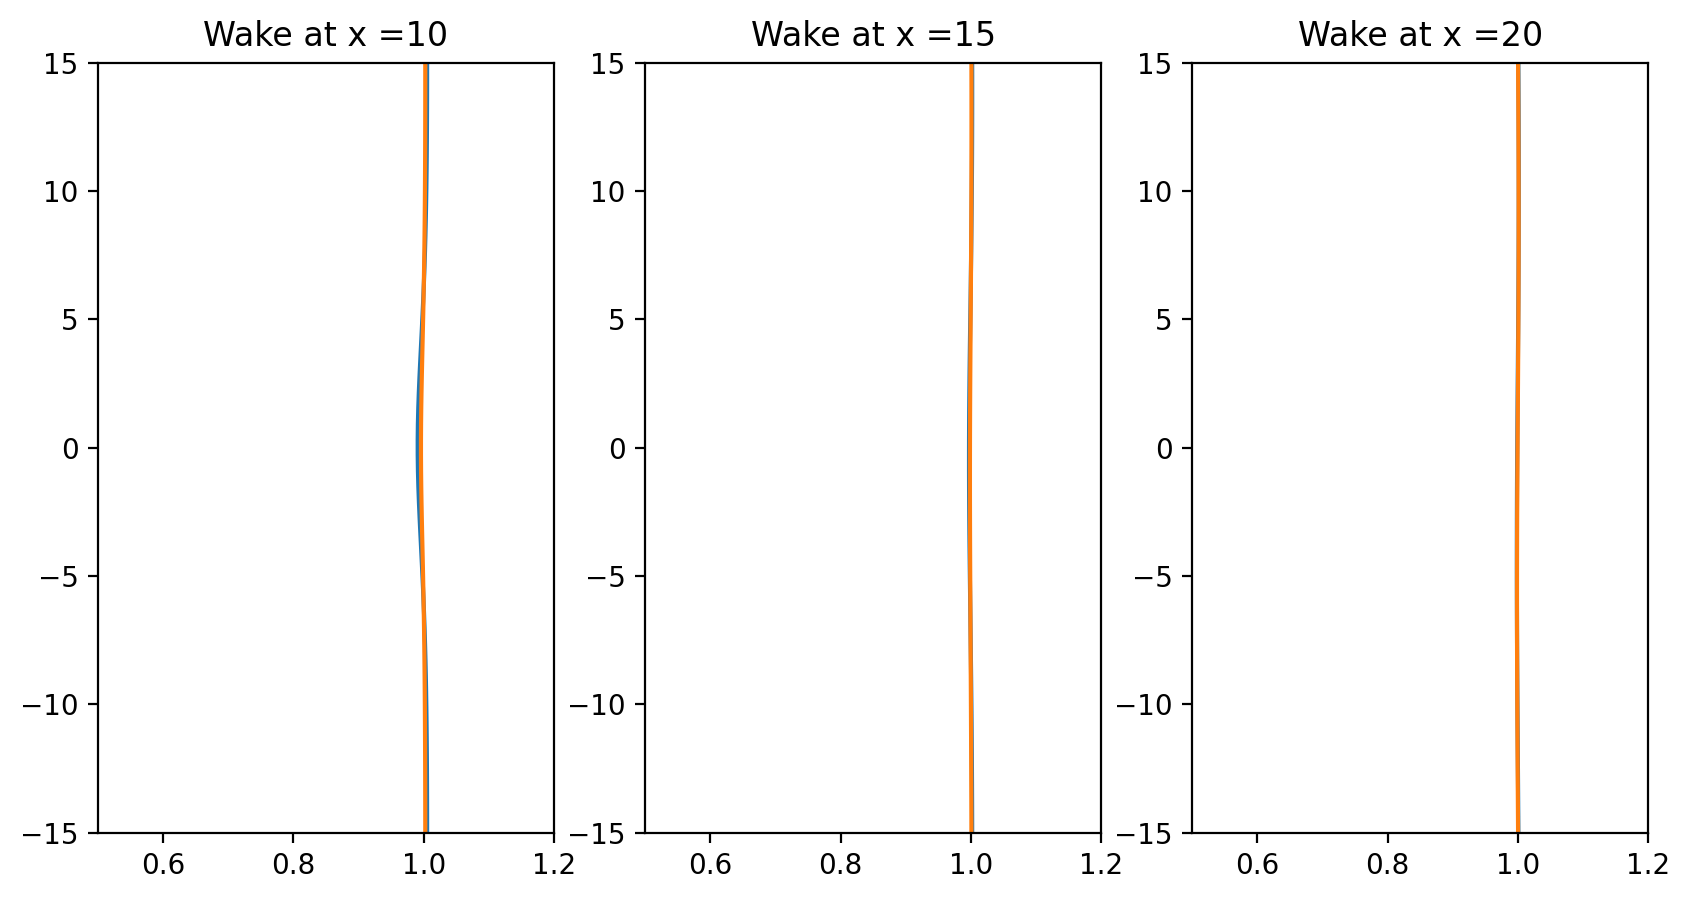

In [6]:
fig, ax = plt.subplots(1, len(wake_positions), figsize=(10, 5), dpi = 200)

for i in range(len(wake_positions)):
    wake_index = np.where(xyz[:,0] == wake_positions[i])
    ax[i].plot(brinkman_wake_u[i,:].flatten(), xyz[wake_index, 1].flatten())
    ax[i].plot(meshed_wake_u[i,:].flatten(), xyz[wake_index, 1].flatten())
    ax[i].set_title('Wake at x ='+str(wake_positions[i]))
    ax[i].set_xlim(U_lims)
    ax[i].set_ylim(y_lims)

plt.show()

# Avereage lift and drag

If this was a surface, we would be integrating the traction $\mathbf{\sigma} \mathbf{n}$ on the boundary, ie,

$\mathbf{F} = \int_{\partial \Omega} \mathbf{\sigma} \mathbf{n} \, dS,$

where $\mathbf{n}$ is the normal vector and $\mathbf{\sigma}$ is the stress tensor, which, for a Newtonian fluid, takes the form $\mathbf{\sigma} = \mu \left( \nabla \mathbf{u} + (\nabla \mathbf{u})^T\right) - \mathbf{I}p$.

Of course this requires $\nabla \mathbf{u}$, so thank god we can rely on Bertie's toolbox to compute gradients in post.

In [7]:
def calculate_forces(msh, fld, ring_radii, n_points, Re):
    from mpi4py import MPI #equivalent to the use of MPI_init() in C
    from pynektools.io.ppymech.neksuite import pynekread
    from pynektools.datatypes.msh import Mesh
    from pynektools.datatypes.coef import Coef
    from pynektools.datatypes.field import FieldRegistry

    # Hide the log for the notebook. Not recommended when running in clusters as it is better you see what happens
    import os
    os.environ["PYNEKTOOLS_HIDE_LOG"] = 'true'
    
    from pynektools.io.ppymech.neksuite import pynekread
    from pynektools.datatypes.msh import Mesh
    from pynektools.datatypes.coef import Coef
    from pynektools.datatypes.field import FieldRegistry
    from pynektools.postprocessing.file_indexing import index_files_from_folder

    from pynektools.interpolation.probes import Probes
    import pynektools.interpolation.utils as interp_utils
    import pynektools.interpolation.pointclouds as pcs

    # Get mpi info
    comm = MPI.COMM_WORLD
    
    # compute derivatives
    coef = Coef(msh, comm, get_area=False)
    dudx = coef.dudxyz(fld.registry['u'], coef.drdx, coef.dsdx, coef.dtdx)
    dudy = coef.dudxyz(fld.registry['u'], coef.drdy, coef.dsdy, coef.dtdx)
    dvdx = coef.dudxyz(fld.registry['v'], coef.drdx, coef.dsdx, coef.dtdx)
    dvdy = coef.dudxyz(fld.registry['v'], coef.drdy, coef.dsdy, coef.dtdx)

    # set up probes
    if comm.Get_rank() == 0 :
    
        # Generate the 1D mesh
        r_1d = np.array(ring_radii)
        th_1d = pcs.generate_1d_arrays([0, 2*np.pi], n_points, mode="equal")
        z_1d = np.array([0.5])
    
        # Generate a 3D mesh
        r, th, z = np.meshgrid(r_1d, th_1d, z_1d, indexing='ij')
        x = r*np.cos(th)
        y = r*np.sin(th)
    
        # Array the points as a list of probes
        xyz = interp_utils.transform_from_array_to_list(len(ring_radii),n_points,1,[x, y, z])
    
    else:
        xyz = None
    
    
    # This sets up the probes interpolation
    ring_probes = Probes(comm, probes = xyz, msh = msh, point_interpolator_type='multiple_point_legendre_numpy', \
                             max_pts=256, find_points_comm_pattern='point_to_point')
    
    # here we actually probe
    ring_probes.interpolate_from_field_list(0, [dudx], comm, write_data=False)
    int_fields = interp_utils.transform_from_list_to_array(len(ring_radii),n_points,1,ring_probes.interpolated_fields)
    dudx = np.copy(int_fields[1])
    
    ring_probes.interpolate_from_field_list(0, [dudy], comm, write_data=False)
    int_fields = interp_utils.transform_from_list_to_array(len(ring_radii),n_points,1,ring_probes.interpolated_fields)
    dudy = np.copy(int_fields[1])
    
    ring_probes.interpolate_from_field_list(0, [dvdx], comm, write_data=False)
    int_fields = interp_utils.transform_from_list_to_array(len(ring_radii),n_points,1,ring_probes.interpolated_fields)
    dvdx = np.copy(int_fields[1])
    
    ring_probes.interpolate_from_field_list(0, [dvdy], comm, write_data=False)
    int_fields = interp_utils.transform_from_list_to_array(len(ring_radii),n_points,1,ring_probes.interpolated_fields)
    dvdy = np.copy(int_fields[1])
    
    ring_probes.interpolate_from_field_list(0, [fld.registry['p']], comm, write_data=False)
    int_fields = interp_utils.transform_from_list_to_array(len(ring_radii),n_points,1,ring_probes.interpolated_fields)
    p = np.copy(int_fields[1])
    
    f_x_visc = np.zeros((len(ring_radii), n_points))
    f_y_visc = np.zeros((len(ring_radii), n_points))
    f_x_p    = np.zeros((len(ring_radii), n_points))
    f_y_p    = np.zeros((len(ring_radii), n_points))
    f_x_tot  = np.zeros((len(ring_radii), n_points))
    f_y_tot  = np.zeros((len(ring_radii), n_points))
    
    f_x_visc_int = np.zeros((len(ring_radii)))
    f_y_visc_int = np.zeros((len(ring_radii)))
    f_x_p_int    = np.zeros((len(ring_radii)))
    f_y_p_int    = np.zeros((len(ring_radii)))
    f_x_tot_int  = np.zeros((len(ring_radii)))
    f_y_tot_int  = np.zeros((len(ring_radii)))
    
    for i in range(len(ring_radii)):
        for j in range(n_points):
            # viscous
            f_x_visc[i,j] = ( dudx[i,j] * 2          * np.cos(th_1d[j]) + \
                             (dudy[i,j] + dvdx[i,j]) * np.sin(th_1d[j]))/Re
            f_y_visc[i,j] = ((dudy[i,j] + dvdx[i,j]) * np.cos(th_1d[j]) + \
                              dvdy[i,j] * 2          * np.sin(th_1d[j]))/Re
            
            #pressure
            f_x_p[i,j] = -p[i,j] * np.cos(th_1d[j])
            f_y_p[i,j] = -p[i,j] * np.sin(th_1d[j])

            # total
            f_x_tot[i,j] = f_x_visc[i,j] + f_x_p[i,j]
            f_y_tot[i,j] = f_y_visc[i,j] + f_y_p[i,j]

    # Here we integrate them around to get a single number
    for i in range(len(ring_radii)):
        ri1 = (n_points)*i
        ri2 = (n_points )*(i+1)
        dS = (2 * np.pi * ring_radii[i]) / n_points
        
        f_x_visc_int[i] = np.sum(f_x_visc[i,:]) * dS
        f_y_visc_int[i] = np.sum(f_y_visc[i,:]) * dS
        f_x_p_int[i]    = np.sum(f_x_p[i,:]) * dS
        f_y_p_int[i]    = np.sum(f_y_p[i,:]) * dS
        
        f_x_tot_int[i] = f_x_visc_int[i] + f_x_p_int[i]
        f_y_tot_int[i] = f_y_visc_int[i] + f_y_p_int[i]

    return f_x_visc, f_y_visc, f_x_p, f_y_p, f_x_tot, f_y_tot, f_x_visc_int, f_y_visc_int, f_x_p_int, f_y_p_int, f_x_tot_int, f_y_tot_int
    

Since we don't have a surface, 

If we take a ring around the cylinder we can probe and integrate the forces around the cylinder.

In [8]:
ring_radii = [0.50, 0.501, 0.502, 0.504, 0.508, 0.516, 0.532]
n_points = 360
Re = 200

brinkman_f_x_visc, brinkman_f_y_visc, brinkman_f_x_p, brinkman_f_y_p, brinkman_f_x_tot, brinkman_f_y_tot, \
brinkman_f_x_visc_int, brinkman_f_y_visc_int, brinkman_f_x_p_int, brinkman_f_y_p_int, brinkman_f_x_tot_int, brinkman_f_y_tot_int = \
calculate_forces(brinkman_msh, brinkman_fld, ring_radii, n_points, Re)

meshed_f_x_visc, meshed_f_y_visc, meshed_f_x_p, meshed_f_y_p, meshed_f_x_tot, meshed_f_y_tot, \
meshed_f_x_visc_int, meshed_f_y_visc_int, meshed_f_x_p_int, meshed_f_y_p_int, meshed_f_x_tot_int, meshed_f_y_tot_int = \
calculate_forces(meshed_msh, meshed_fld, ring_radii, n_points, Re)

2024-11-10 16:04:25,501 - Coef - INFO - Initializing Coef object
2024-11-10 16:04:25,502 - Coef - INFO - Getting derivative matrices
2024-11-10 16:04:25,507 - Coef - INFO - Calculating the components of the jacobian
2024-11-10 16:04:25,772 - Coef - INFO - Calculating the jacobian determinant and inverse of the jacobian matrix
2024-11-10 16:04:25,818 - Coef - INFO - Calculating the mass matrix
2024-11-10 16:04:25,819 - Coef - INFO - Coef object initialized
2024-11-10 16:04:25,819 - Coef - INFO - Coef data is of type: float64
2024-11-10 16:04:25,820 - Coef - INFO - Elapsed time: 0.318841582000001s
2024-11-10 16:04:25,820 - Coef - INFO - Calculating the derivative with respect to physical coordinates
2024-11-10 16:04:25,916 - Coef - INFO - done
2024-11-10 16:04:25,916 - Coef - INFO - Elapsed time: 0.09621143400000065s
2024-11-10 16:04:25,917 - Coef - INFO - Calculating the derivative with respect to physical coordinates
2024-11-10 16:04:26,010 - Coef - INFO - done
2024-11-10 16:04:26,010 

/tmp/user/12792/ipykernel_1470204/2681168278.py:94: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f_x_visc[i,j] = ( dudx[i,j] * 2          * np.cos(th_1d[j]) + \
/tmp/user/12792/ipykernel_1470204/2681168278.py:96: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f_y_visc[i,j] = ((dudy[i,j] + dvdx[i,j]) * np.cos(th_1d[j]) + \
/tmp/user/12792/ipykernel_1470204/2681168278.py:100: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f_x_p[i,j] = -p[i,j] * np.cos(th_1d[j])
/tmp/u

2024-11-10 16:04:28,711 - Coef - INFO - Calculating the jacobian determinant and inverse of the jacobian matrix
2024-11-10 16:04:28,807 - Coef - INFO - Calculating the mass matrix
2024-11-10 16:04:28,812 - Coef - INFO - Coef object initialized
2024-11-10 16:04:28,813 - Coef - INFO - Coef data is of type: float64
2024-11-10 16:04:28,813 - Coef - INFO - Elapsed time: 0.4783392269999993s
2024-11-10 16:04:28,814 - Coef - INFO - Calculating the derivative with respect to physical coordinates
2024-11-10 16:04:28,950 - Coef - INFO - done
2024-11-10 16:04:28,952 - Coef - INFO - Elapsed time: 0.13751389899999822s
2024-11-10 16:04:28,953 - Coef - INFO - Calculating the derivative with respect to physical coordinates
2024-11-10 16:04:29,091 - Coef - INFO - done
2024-11-10 16:04:29,092 - Coef - INFO - Elapsed time: 0.13761107199999856s
2024-11-10 16:04:29,092 - Coef - INFO - Calculating the derivative with respect to physical coordinates
2024-11-10 16:04:29,226 - Coef - INFO - done
2024-11-10 16:0

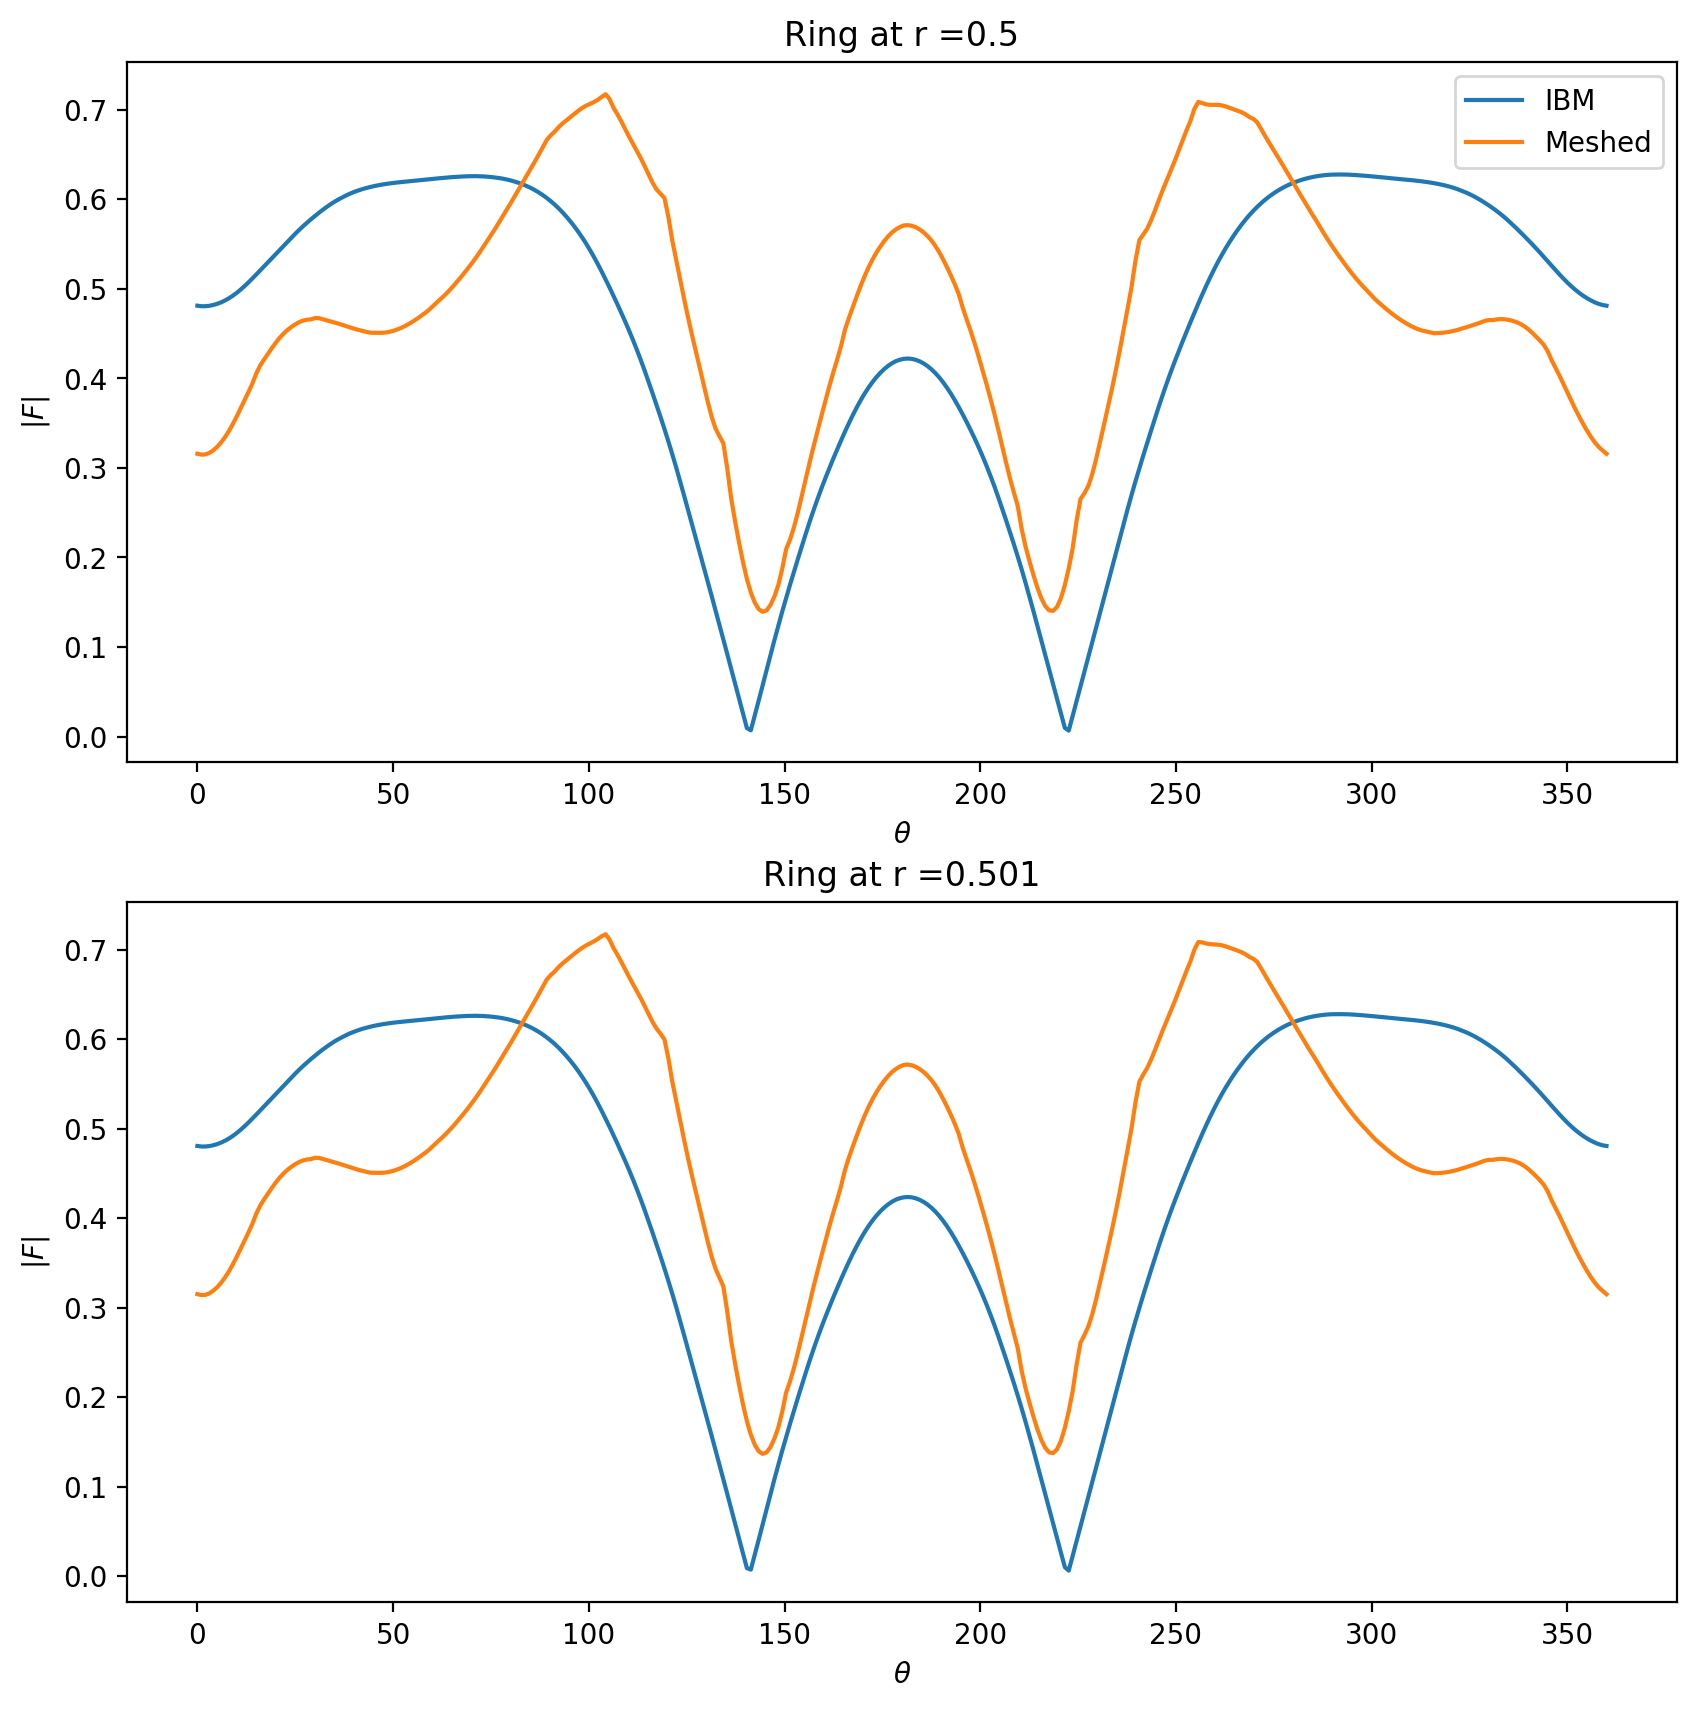

In [9]:
import pynektools.interpolation.pointclouds as pcs
th_1d = pcs.generate_1d_arrays([0, 2*np.pi], n_points, mode="equal")

fig, ax = plt.subplots(2,1, figsize=(10, 10), dpi = 200)

# lets just look at 2
for i in range(2):
    ax[i].plot(th_1d/np.pi*180, np.sqrt(brinkman_f_x_tot[i,:]**2 + brinkman_f_y_tot[i,:]**2), label='IBM')
    ax[i].plot(th_1d/np.pi*180, np.sqrt(meshed_f_x_tot[i,:]**2 + meshed_f_y_tot[i,:]**2), label='Meshed')
    ax[i].set_title('Ring at r ='+str(ring_radii[i]))
    ax[i].set_xlabel(r'$\theta$')
    ax[i].set_ylabel(r'$|F|$')
ax[0].legend()
plt.show()

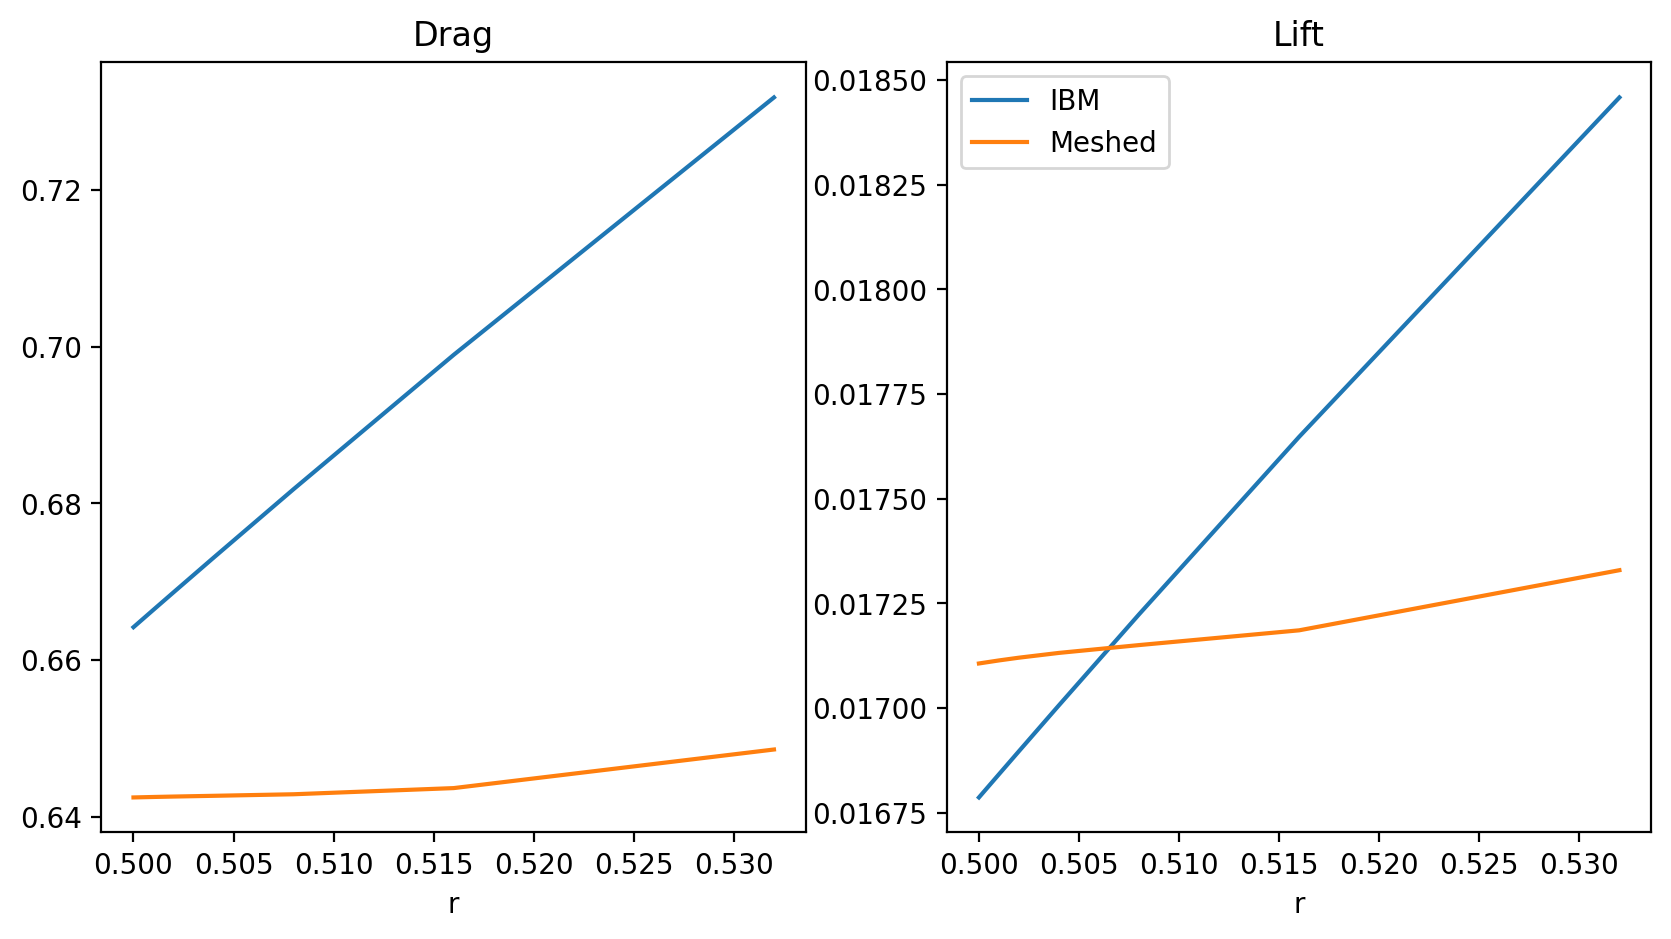

In [10]:
# Maybe look at how lift and drag changes with the circle we take:
fig, ax = plt.subplots(1,2, figsize=(10, 5), dpi = 200)
ax[0].plot(ring_radii, brinkman_f_x_tot_int)
ax[0].plot(ring_radii, meshed_f_x_tot_int)
ax[0].set_title('Drag')
ax[0].set_xlabel('r')

ax[1].plot(ring_radii, brinkman_f_y_tot_int, label='IBM')
ax[1].plot(ring_radii, meshed_f_y_tot_int, label='Meshed')
ax[1].set_title('Lift')
ax[1].set_xlabel('r')
ax[1].legend()
plt.show()

# Vorticity

For post processing nice videos it's alway nice to show vorticity instead of velocity.

Again, Berties tools allow us compute vorticity in aposteri.

In [11]:
def compute_vorticity(path_name, file_name):

    from mpi4py import MPI #equivalent to the use of MPI_init() in C
    from pynektools.io.ppymech.neksuite import pynekread
    from pynektools.datatypes.msh import Mesh
    from pynektools.datatypes.coef import Coef
    from pynektools.datatypes.field import FieldRegistry
    
    # Readers
    from pynektools.io.ppymech.neksuite import preadnek, pynekread
    
    # Writers
    from pynektools.io.ppymech.neksuite import pwritenek, pynekwrite
    
    from pynektools.postprocessing.file_indexing import index_files_from_folder
    
    # Get mpi info
    comm = MPI.COMM_WORLD
    
    # Hide the log for the notebook. Not recommended when running in clusters as it is better you see what happens
    import os
    os.environ["PYNEKTOOLS_HIDE_LOG"] = 'true'


    # ------------------------------------------------------------------------------------
    # just do the first one for the mesh
    # set mesh and fld
    msh = Mesh(comm, create_connectivity=True)
    fld = FieldRegistry(comm)
    fld_out = FieldRegistry(comm)
    
    # remember the mesh is only stored in the first one!
    # here we're just getting the mesh
    pynekread(path_name + file_name +'.f00000', comm, data_dtype=np.single, msh=msh, fld=fld)
    
    # compute derivatives
    coef = Coef(msh, comm, get_area=False)
    u = fld.fields['vel'][0]
    v = fld.fields['vel'][1]
    dudy = coef.dudxyz(u, coef.drdy, coef.dsdy, coef.dtdx)
    dvdx = coef.dudxyz(v, coef.drdx, coef.dsdx, coef.dtdx)
    
    # compute vorticity
    vort = dvdx - dudy

    # TODO
    # Maybe we wan't a gsop here if it looks ugly!
    
    # add to the registry of output
    fld_out.fields['scal'].append(vort)
    fld_out.update_vars()
    
    # write it out
    file_name_out = path_name + 'vort0.f00000'
    pynekwrite(file_name_out, comm, msh=msh, fld=fld_out, write_mesh=True, wdsz=4)
    
    # ------------------------------------------------------------------------------------
    # now we can do all the remain files
    i = 1
    file_exists = True
    while file_exists:
        f_in = path_name + file_name  + '.f' + "{:05d}".format(i)
        file_exists = os.path.isfile(f_in)
        if not file_exists:
            break
    
        # new field
        fld = FieldRegistry(comm)
        fld_out = FieldRegistry(comm)
    
        # now we don't need the mesh or coef
        pynekread(f_in, comm, data_dtype=np.single, fld=fld)
    
        u = fld.fields['vel'][0]
        v = fld.fields['vel'][1]
        dudy = coef.dudxyz(u, coef.drdy, coef.dsdy, coef.dtdx)
        dvdx = coef.dudxyz(v, coef.drdx, coef.dsdx, coef.dtdx)
        
        # compute vorticity
        vort = dvdx - dudy
    
        # TODO
        # Maybe we wan't a gsop here if it looks ugly!
    
        # add to registry
        fld_out.fields['scal'].append(vort)
        fld_out.update_vars()
        
        # write it out
        file_name_out = path_name + 'vort0'  + '.f' + "{:05d}".format(i)
        pynekwrite(file_name_out, comm, msh=msh, fld=fld_out, write_mesh=False, wdsz=4)
    
        
        print(f_in)
        i += 1



### Visulization

I would envision the actual post processing will be done in `visit` or `paraview`, but here we'll just take a little looking in this notebook.


In [12]:
# compute the vorticity
compute_vorticity(results_path + brinkman_path + 'field0/', 'field0')
compute_vorticity(results_path + meshed_path + 'field0/', 'field0')

2024-11-10 16:04:33,795 - Mesh - INFO - Initializing empty Mesh object.
2024-11-10 16:04:33,798 - Field - INFO - Initializing empty Field object
2024-11-10 16:04:33,799 - Field - INFO - Initializing empty Field object
2024-11-10 16:04:33,800 - pynekread - INFO - Reading file: ../../../results/brinkman_parameters/dt_check/brinkman/field0/field0.f00000
2024-11-10 16:04:33,810 - Mesh - INFO - Initializing Mesh object from x,y,z ndarrays.
2024-11-10 16:04:33,811 - Mesh - INFO - Initializing common attributes.
2024-11-10 16:04:33,813 - Mesh - INFO - Getting vertices
2024-11-10 16:04:33,816 - Mesh - INFO - Getting edge centers
2024-11-10 16:04:33,841 - Mesh - INFO - Getting facet centers
2024-11-10 16:04:33,865 - Mesh - INFO - Creating connectivity
2024-11-10 16:04:35,590 - Mesh - INFO - Mesh object initialized.
2024-11-10 16:04:35,591 - Mesh - INFO - Mesh data is of type: float32
2024-11-10 16:04:35,591 - Mesh - INFO - Elapsed time: 1.781253588000002s
2024-11-10 16:04:35,592 - pynekread - I

In [13]:
# load in the vorticty and plot
vort_brinkman_msh, vort_brinkman_fld = load_stats_file(results_path + brinkman_path + 'field0/vort0', 1)
vort_meshed_msh, vort_meshed_fld = load_stats_file(results_path + meshed_path + 'field0/vort0', 1)

2024-11-10 16:04:39,390 - Mesh - INFO - Initializing empty Mesh object.
2024-11-10 16:04:39,390 - Field - INFO - Initializing empty Field object
2024-11-10 16:04:39,391 - pynekread - INFO - Reading file: ../../../results/brinkman_parameters/dt_check/brinkman/field0/vort0.f00000
2024-11-10 16:04:39,407 - Mesh - INFO - Initializing Mesh object from x,y,z ndarrays.
2024-11-10 16:04:39,408 - Mesh - INFO - Initializing common attributes.
2024-11-10 16:04:39,408 - Mesh - INFO - Getting vertices
2024-11-10 16:04:39,409 - Mesh - INFO - Getting edge centers
2024-11-10 16:04:39,449 - Mesh - INFO - Getting facet centers
2024-11-10 16:04:39,498 - Mesh - INFO - Creating connectivity
2024-11-10 16:04:41,175 - Mesh - INFO - Mesh object initialized.
2024-11-10 16:04:41,178 - Mesh - INFO - Mesh data is of type: float64
2024-11-10 16:04:41,179 - Mesh - INFO - Elapsed time: 1.7715716069999985s
2024-11-10 16:04:41,180 - pynekread - INFO - File read
2024-11-10 16:04:41,181 - pynekread - INFO - Elapsed time

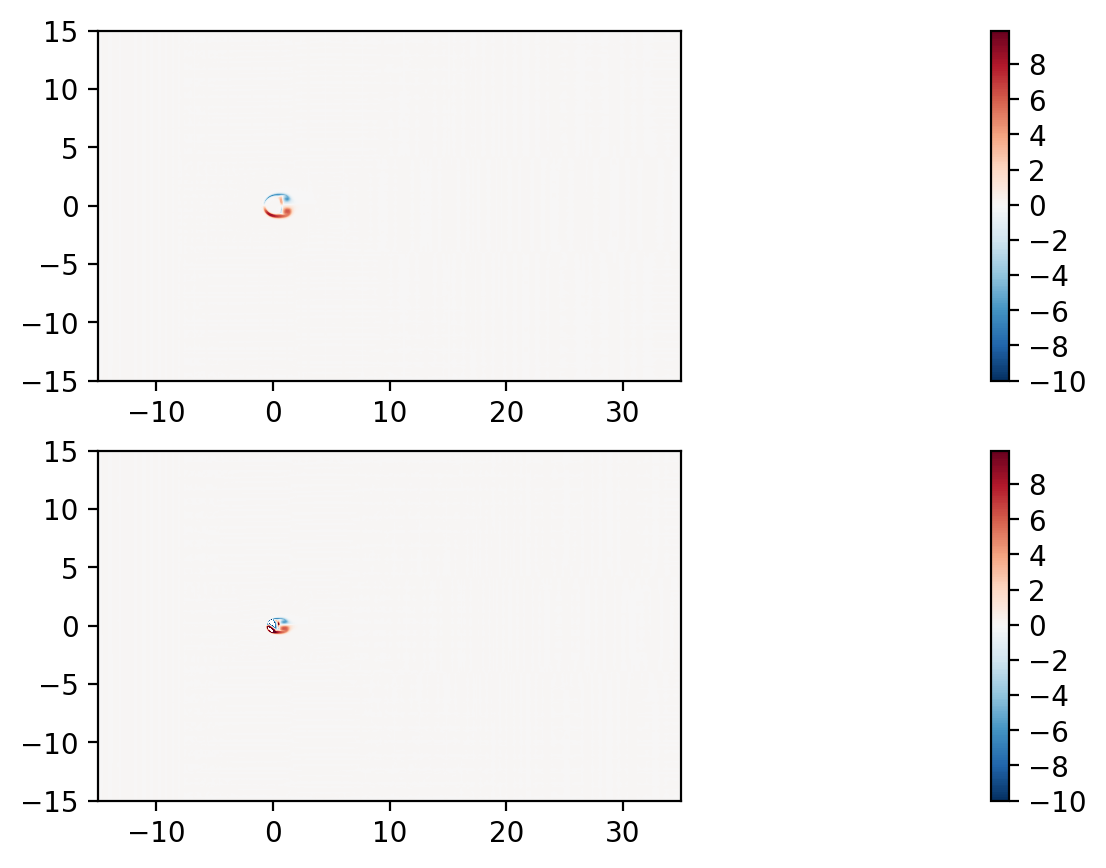

In [14]:
fig, ax = plt.subplots(2,1, figsize=(40, 5), dpi = 200)
c = ax[0].tricontourf(brinkman_msh.x.flatten(), brinkman_msh.y.flatten() ,vort_brinkman_fld.fields['scal'][0].flatten(), levels=np.arange(start=-10, stop=10, step=0.1), cmap="RdBu_r")
fig.colorbar(c)
ax[0].set_aspect('equal')
c = ax[1].tricontourf(meshed_msh.x.flatten(), meshed_msh.y.flatten() ,vort_meshed_fld.fields['scal'][0].flatten(), levels=np.arange(start=-10, stop=10, step=0.1), cmap="RdBu_r")
fig.colorbar(c)
ax[1].set_aspect('equal')
plt.show()